In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F
from collections import defaultdict
import re
import numpy as np

In [ ]:
# The version of the data loaded here is covert only, and the X is principal components
X,y = np.load("gamma_epochs_pca.npz").values()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1)).reshape(X_test.shape)

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

In [14]:
class CNN_LSTM_Classifier(nn.Module):
    def __init__(self, n_channels, n_timepoints, n_classes=4):
        super(CNN_LSTM_Classifier, self).__init__()
        
        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=7, padding=2)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=9, padding=1)
        
        self.pool = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.3)
        
        self.lstm = nn.LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3)
        self.dropout2 = nn.Dropout(0.5)
        
        self.classifier = nn.Linear(64, n_classes)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        
        x = self.dropout1(x)
        
        x = x.transpose(1, 2)
        
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        x = lstm_out[:, -1, :]
        
        x = self.dropout2(x)
        x = self.classifier(x)
        
        return x

n_channels = X_train_tensor.shape[1]
n_timepoints = X_train_tensor.shape[2]
n_classes = 4

model = CNN_LSTM_Classifier(n_channels, n_timepoints, n_classes)
print(model)

device = torch.device('cpu')
print(f"Using device: {device}")

X_train_tensor = X_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


CNN_LSTM_Classifier(
  (conv1): Conv1d(14, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(2,))
  (conv3): Conv1d(64, 128, kernel_size=(9,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout2): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)
Using device: cpu


In [15]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)
    
    return total_loss / len(train_loader), 100. * correct / total

def test_epoch(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            
            all_preds.extend(pred.cpu().numpy().flatten())
            all_targets.extend(target.cpu().numpy())
    
    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    
    return test_loss, accuracy, all_preds, all_targets

num_epochs = 100
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = test_epoch(model, test_loader, criterion, device)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
            f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

Epoch   0: Train Loss: 1.3562, Train Acc: 33.81%, Test Loss: 1.3316, Test Acc: 40.57%
Epoch  10: Train Loss: 1.3439, Train Acc: 40.00%, Test Loss: 1.3319, Test Acc: 40.57%
Epoch  20: Train Loss: 1.1102, Train Acc: 48.81%, Test Loss: 1.4400, Test Acc: 25.47%
Epoch  30: Train Loss: 0.7461, Train Acc: 66.90%, Test Loss: 1.9938, Test Acc: 19.81%
Epoch  40: Train Loss: 0.4528, Train Acc: 84.05%, Test Loss: 2.9838, Test Acc: 27.36%
Epoch  50: Train Loss: 0.2466, Train Acc: 94.05%, Test Loss: 3.8647, Test Acc: 26.42%
Epoch  60: Train Loss: 0.0962, Train Acc: 98.33%, Test Loss: 4.2421, Test Acc: 28.30%
Epoch  70: Train Loss: 0.0713, Train Acc: 98.81%, Test Loss: 4.6089, Test Acc: 26.42%
Epoch  80: Train Loss: 0.0289, Train Acc: 99.76%, Test Loss: 4.8664, Test Acc: 27.36%
Epoch  90: Train Loss: 0.0714, Train Acc: 98.57%, Test Loss: 4.5731, Test Acc: 25.47%
Epoch  99: Train Loss: 0.0262, Train Acc: 99.76%, Test Loss: 4.8005, Test Acc: 28.30%



FINAL RESULTS - CNN-LSTM Directional Movement Classifier
Final Test Accuracy: 28.30%

Classification Report:
              precision    recall  f1-score   support

          up       0.14      0.14      0.14        21
        down       0.13      0.19      0.15        21
        left       0.22      0.19      0.21        21
       right       0.53      0.44      0.48        43

    accuracy                           0.28       106
   macro avg       0.26      0.24      0.25       106
weighted avg       0.31      0.28      0.29       106


Confusion Matrix:
[[ 3  9  2  7]
 [ 8  4  2  7]
 [ 5  9  4  3]
 [ 5  9 10 19]]


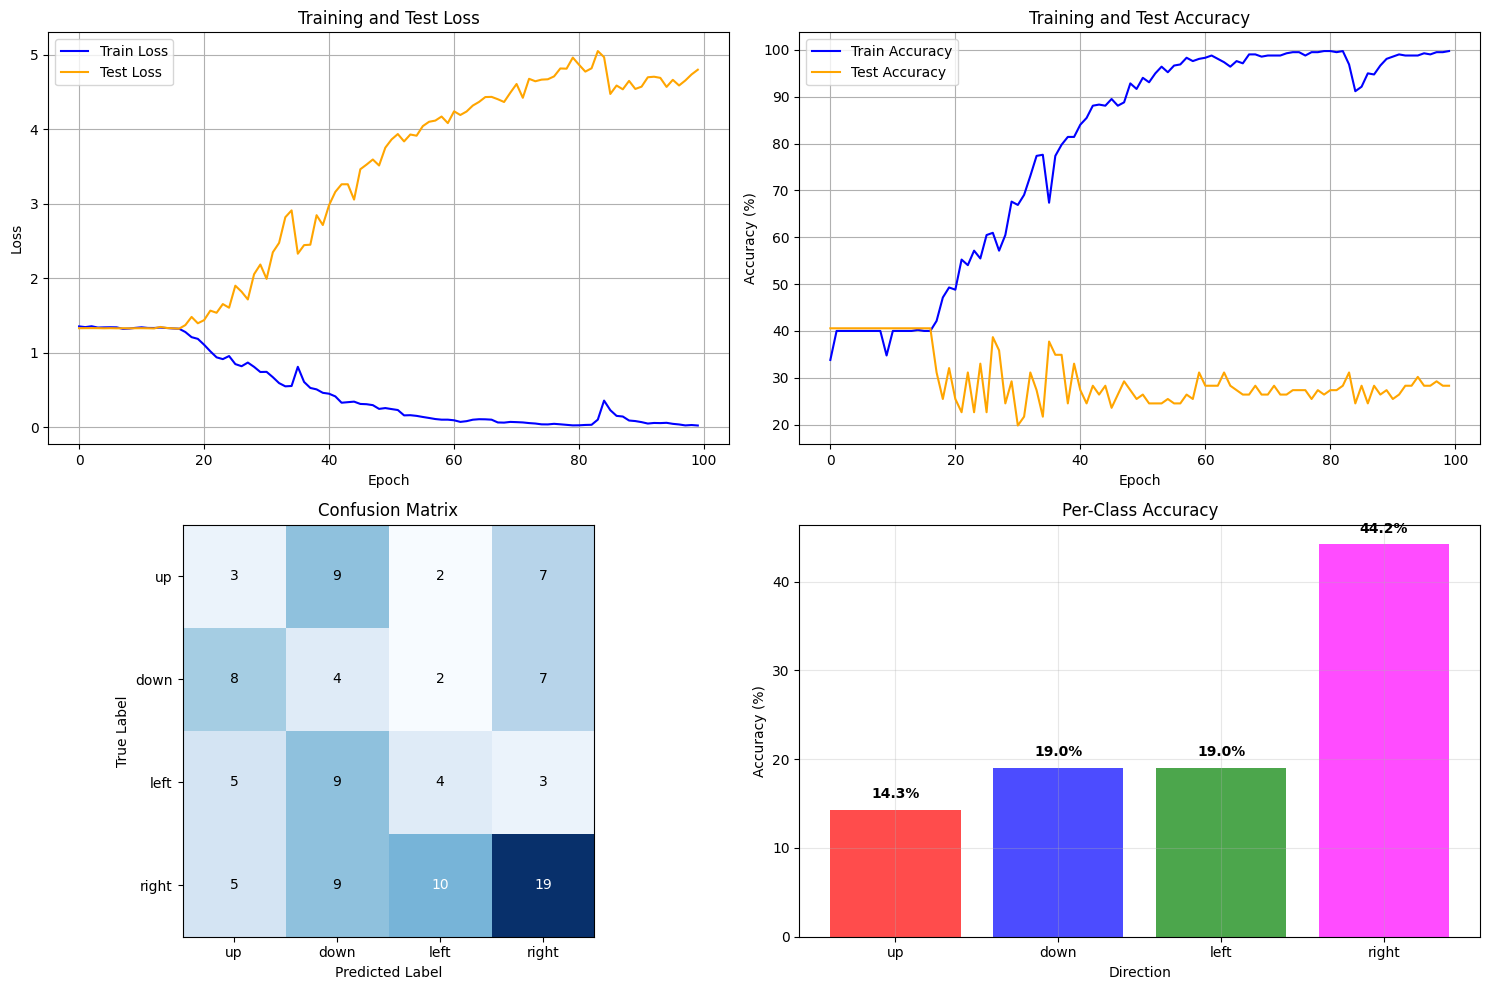


Per-class accuracy:
  UP: 14.3%
  DOWN: 19.0%
  LEFT: 19.0%
  RIGHT: 44.2%

Model Summary:
  - Input: 14 EEG channels, 154 time points
  - Gamma frequency band: 30-100 Hz
  - Architecture: 1D CNN + LSTM
  - Parameters: 173,732
  - Training epochs: 100
  - Final accuracy: 28.30%


In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

_, final_test_acc, test_preds, test_targets = test_epoch(model, test_loader, criterion, device)

print(f"\n{'='*60}")
print(f"FINAL RESULTS - CNN-LSTM Directional Movement Classifier")
print(f"{'='*60}")
print(f"Final Test Accuracy: {final_test_acc:.2f}%")

class_names = ['up', 'down', 'left', 'right']
print(f"\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=class_names))

print(f"\nConfusion Matrix:")
cm = confusion_matrix(test_targets, test_preds)
print(cm)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].plot(train_losses, label='Train Loss', color='blue')
axes[0,0].plot(test_losses, label='Test Loss', color='orange')
axes[0,0].set_title('Training and Test Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(train_accuracies, label='Train Accuracy', color='blue')
axes[0,1].plot(test_accuracies, label='Test Accuracy', color='orange')
axes[0,1].set_title('Training and Test Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].legend()
axes[0,1].grid(True)

im = axes[1,0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[1,0].set_title('Confusion Matrix')
tick_marks = np.arange(len(class_names))
axes[1,0].set_xticks(tick_marks)
axes[1,0].set_xticklabels(class_names)
axes[1,0].set_yticks(tick_marks)
axes[1,0].set_yticklabels(class_names)
axes[1,0].set_ylabel('True Label')
axes[1,0].set_xlabel('Predicted Label')

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    axes[1,0].text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100
colors = ['red', 'blue', 'green', 'magenta']
bars = axes[1,1].bar(class_names, class_accuracy, color=colors, alpha=0.7)
axes[1,1].set_title('Per-Class Accuracy')
axes[1,1].set_xlabel('Direction')
axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].grid(True, alpha=0.3)

for i, (bar, acc) in enumerate(zip(bars, class_accuracy)):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nPer-class accuracy:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name.upper()}: {class_accuracy[i]:.1f}%")

print(f"\nModel Summary:")
print(f"  - Input: {n_channels} EEG channels, {n_timepoints} time points")
print(f"  - Gamma frequency band: 30-100 Hz")
print(f"  - Architecture: 1D CNN + LSTM")
print(f"  - Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  - Training epochs: {num_epochs}")
print(f"  - Final accuracy: {final_test_acc:.2f}%")